#  piNEUMA Parser for Local Folder
This notebook loads and parses **all piNEUMA CSV files** from the local `data/` folder.

In [1]:
# 1) Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [2]:
# 2) Set path to your local folder
folder_path = '../data'  # path relative to notebooks folder
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
dataframes = {}

Parse each file into a labeled dataframe

In [3]:

# 3) Parse each file into a labeled DataFrame
for file_path in csv_files:
    filename = os.path.basename(file_path)
    parts = filename.split('_')

    if len(parts) < 3:
        print(f"Skipping file with unexpected format: {filename}")
        continue

    date_str = parts[0]
    location_str = parts[1]
    start_time_str = parts[2]
    monthday = date_str[4:]

    loc_num = location_str.replace("d", "")
    loc_label = f"L{loc_num}"

    if start_time_str.startswith("0"):
        start_time_str = start_time_str[1:]

    var_name = f"df_{loc_label}{start_time_str}_{monthday}"

    rows = []
    with open(file_path, 'r', encoding='utf-8') as f:
        next(f)
        for line_num, line in enumerate(f, start=2):
            if line_num > 2000:
                break
            fields = line.strip().split(';')
            if len(fields) < 4:
                continue

            track_id    = fields[0]
            vehicle_type = fields[1]
            traveled_d  = fields[2]
            avg_speed   = fields[3]
            time_step_fields = fields[4:]

            while time_step_fields and not time_step_fields[-1].strip():
                time_step_fields.pop()

            leftover = len(time_step_fields) % 6
            if leftover != 0:
                time_step_fields = time_step_fields[:-leftover]

            n_blocks = len(time_step_fields) // 6

            for i in range(n_blocks):
                offset = i * 6
                lat     = time_step_fields[offset + 0]
                lon     = time_step_fields[offset + 1]
                speed   = time_step_fields[offset + 2]
                lon_acc = time_step_fields[offset + 3]
                lat_acc = time_step_fields[offset + 4]
                tstamp  = time_step_fields[offset + 5]
                rows.append({
                    "track_id":   track_id,
                    "type":       vehicle_type,
                    "traveled_d": traveled_d,
                    "avg_speed":  avg_speed,
                    "lat":        lat,
                    "lon":        lon,
                    "speed":      speed,
                    "lon_acc":    lon_acc,
                    "lat_acc":    lat_acc,
                    "time":       tstamp,
                    "time_step":  i
                })

    df = pd.DataFrame(rows)
    numeric_cols = ["traveled_d", "avg_speed", "lat", "lon", "speed", "lon_acc", "lat_acc", "time"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    dataframes[var_name] = df
    print(f"Parsed {filename} -> {var_name} with shape: {df.shape}")

Parsed 20181024_dX_0830_0900 (1).csv -> df_LX830_1024 with shape: (8333923, 11)
Parsed 20181024_dX_1030_1100.csv -> df_LX1030_1024 with shape: (8743536, 11)
Parsed 20181024_dX_0900_0930.csv -> df_LX900_1024 with shape: (10297119, 11)


In [4]:
# One example
list(dataframes.keys())

['df_LX830_1024', 'df_LX1030_1024', 'df_LX900_1024']

Preview dataframes

In [5]:
# 4)Preview one of the parsed DataFrames
sample_key = list(dataframes.keys())[0]
dataframes[sample_key].head()

,track_id,type,traveled_d,avg_speed,lat,lon,speed,lon_acc,lat_acc,time,time_step
0,1,Car,10.18,36.634649,37.984642,23.724906,38.1611,0.0,0.0,0.00,0
1,1,Car,10.18,36.634649,37.984643,23.724901,38.1611,0.0,0.0,0.04,1
2,1,Car,10.18,36.634649,37.984643,23.724896,38.1611,0.0,0.0,0.08,2
3,1,Car,10.18,36.634649,37.984644,23.724892,38.1611,0.0,0.0,0.12,3
4,1,Car,10.18,36.634649,37.984645,23.724887,38.1611,0.0,0.0,0.16,4


Check vehicle type count and percentage 

In [6]:
# check vehicle_type % and count
for name, df in dataframes.items():
    print(f"\n Analyzing: {name}")
    
    unique_vehicles = df.drop_duplicates(subset=["track_id"])
    vehicle_type_counts = unique_vehicles["type"].value_counts()
    vehicle_type_percentage = unique_vehicles["type"].value_counts(normalize=True) * 100

    print("Vehicle Type Counts:")
    print(vehicle_type_counts)

    print("\nVehicle Type Percentages (%):")
    print(vehicle_type_percentage)


 Analyzing: df_LX830_1024
Vehicle Type Counts:
type
Car               993
Motorcycle        540
Taxi              292
Medium Vehicle     84
Bus                52
Heavy Vehicle      38
Name: count, dtype: int64

Vehicle Type Percentages (%):
type
Car               49.674837
Motorcycle        27.013507
Taxi              14.607304
Medium Vehicle     4.202101
Bus                2.601301
Heavy Vehicle      1.900950
Name: proportion, dtype: float64

 Analyzing: df_LX1030_1024
Vehicle Type Counts:
type
Car               790
Motorcycle        579
Taxi              418
Medium Vehicle    133
Bus                58
Heavy Vehicle      21
Name: count, dtype: int64

Vehicle Type Percentages (%):
type
Car               39.519760
Motorcycle        28.964482
Taxi              20.910455
Medium Vehicle     6.653327
Bus                2.901451
Heavy Vehicle      1.050525
Name: proportion, dtype: float64

 Analyzing: df_LX900_1024
Vehicle Type Counts:
type
Car               958
Motorcycle        492
Taxi  

In [7]:
#Flow

In [8]:
bin_width = 10  # seconds

for name, df in dataframes.items():
    print(f"\n Flow analysis for: {name}")
    
    # Create a time bin column
    df["time_bin"] = (df["time"] // bin_width).astype(int)
    
    # Count unique vehicles in each time bin
    flow_df = df.groupby("time_bin")["track_id"].nunique().reset_index(name="unique_vehicle_count")
    
    # Convert to flow in vehicles/hour
    flow_df["flow"] = flow_df["unique_vehicle_count"] * (3600 / bin_width)
    
    print(flow_df.head())


 Flow analysis for: df_LX830_1024


   time_bin  unique_vehicle_count      flow
0         0                  1058  380880.0
1         1                  1138  409680.0
2         2                  1306  470160.0
3         3                  1338  481680.0
4         4                  1346  484560.0

 Flow analysis for: df_LX1030_1024
   time_bin  unique_vehicle_count      flow
0         0                  1747  628920.0
1         1                  1813  652680.0
2         2                  1833  659880.0
3         3                  1743  627480.0
4         4                  1661  597960.0

 Flow analysis for: df_LX900_1024
   time_bin  unique_vehicle_count      flow
0         0                  1787  643320.0
1         1                  1836  660960.0
2         2                  1851  666360.0
3         3                  1746  628560.0
4         4                  1650  594000.0


Density

In [9]:
bin_width = 10  # seconds
segment_length_km = 1.0  # assumed constant for now

for name, df in dataframes.items():
    print(f"\n Flow + Density analysis for: {name}")
    
    df["time_bin"] = (df["time"] // bin_width).astype(int)
    
    flow_df = df.groupby("time_bin")["track_id"].nunique().reset_index(name="unique_vehicle_count")
    flow_df["flow"] = flow_df["unique_vehicle_count"] * (3600 / bin_width)
    flow_df["density"] = flow_df["unique_vehicle_count"] / segment_length_km
    
    print(flow_df[["time_bin", "flow", "density"]].head())
    


 Flow + Density analysis for: df_LX830_1024
   time_bin      flow  density
0         0  380880.0   1058.0
1         1  409680.0   1138.0
2         2  470160.0   1306.0
3         3  481680.0   1338.0
4         4  484560.0   1346.0

 Flow + Density analysis for: df_LX1030_1024
   time_bin      flow  density
0         0  628920.0   1747.0
1         1  652680.0   1813.0
2         2  659880.0   1833.0
3         3  627480.0   1743.0
4         4  597960.0   1661.0

 Flow + Density analysis for: df_LX900_1024
   time_bin      flow  density
0         0  643320.0   1787.0
1         1  660960.0   1836.0
2         2  666360.0   1851.0
3         3  628560.0   1746.0
4         4  594000.0   1650.0


Average speed

In [10]:
bin_width = 10  # seconds

for name, df in dataframes.items():
    print(f"\n Speed analysis for: {name}")
    
    # Time bin column (in case it's not there yet)
    df["time_bin"] = (df["time"] // bin_width).astype(int)

    # Average speed per vehicle
    vehicle_avg = df.groupby("track_id")["speed"].mean().reset_index(name="vehicle_avg_speed")
    unique_vehicle_info = df.drop_duplicates(subset=["track_id"])[["track_id", "type"]]
    vehicle_avg = vehicle_avg.merge(unique_vehicle_info, on="track_id", how="left")

    # Average speed by vehicle type
    avg_speed_by_type = vehicle_avg.groupby("type")["vehicle_avg_speed"].mean().reset_index()
    print(" Average Speed by Vehicle Type:")
    print(avg_speed_by_type)

    # Average speed per time bin
    speed_df = df.groupby("time_bin")["speed"].mean().reset_index(name="avg_speed")
    print("\n Average Speed per Time Bin (km/h):")
    print(speed_df.head())


 Speed analysis for: df_LX830_1024
 Average Speed by Vehicle Type:
              type  vehicle_avg_speed
0              Bus          12.193180
1              Car          14.568032
2    Heavy Vehicle           7.462846
3   Medium Vehicle          11.954133
4       Motorcycle          20.324801
5             Taxi          14.254695

 Average Speed per Time Bin (km/h):
   time_bin  avg_speed
0         0  13.649858
1         1  15.157980
2         2  15.730261
3         3  15.745717
4         4  14.763552

 Speed analysis for: df_LX1030_1024
 Average Speed by Vehicle Type:
              type  vehicle_avg_speed
0              Bus           8.594237
1              Car          11.584282
2    Heavy Vehicle           7.881595
3   Medium Vehicle           9.172533
4       Motorcycle          17.433268
5             Taxi          12.669395

 Average Speed per Time Bin (km/h):
   time_bin  avg_speed
0         0  11.662956
1         1  10.624024
2         2  11.438292
3         3  11.722281
4   

Time statistics

In [11]:
for name, df in dataframes.items():
    print(f"\nTime stats for: {name}")
    
    df = df.copy()
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    print(df[["track_id", "time"]].head())  # optional preview

    print("Min time:", df["time"].min())
    print("Max time:", df["time"].max())
    print("Total duration (s):", df["time"].max() - df["time"].min())

    print("\n" + "-"*40)


Time stats for: df_LX830_1024
  track_id  time
0        1  0.00
1        1  0.04
2        1  0.08
3        1  0.12
4        1  0.16
Min time: 0.0
Max time: 787.56
Total duration (s): 787.56

----------------------------------------

Time stats for: df_LX1030_1024
  track_id  time
0        1  0.00
1        1  0.04
2        1  0.08
3        1  0.12
4        1  0.16
Min time: 0.0
Max time: 450.96
Total duration (s): 450.96

----------------------------------------

Time stats for: df_LX900_1024
  track_id  time
0        1  0.00
1        1  0.04
2        1  0.08
3        1  0.12
4        1  0.16
Min time: 0.0
Max time: 882.32
Total duration (s): 882.32

----------------------------------------


Step-by-step implementation

In [12]:
from geopy.distance import distance

lat_min = df["lat"].min()
lat_max = df["lat"].max()
lon_min = df["lon"].min()
lon_max = df["lon"].max()


corner1 = (lat_min, lon_min)
corner2 = (lat_max, lon_max)
approx_meters = distance(corner1, corner2).meters
corridor_length_km = approx_meters / 1000.0

lat_upstream = (lat_min + lat_max) / 2.0

Apply all dataframes

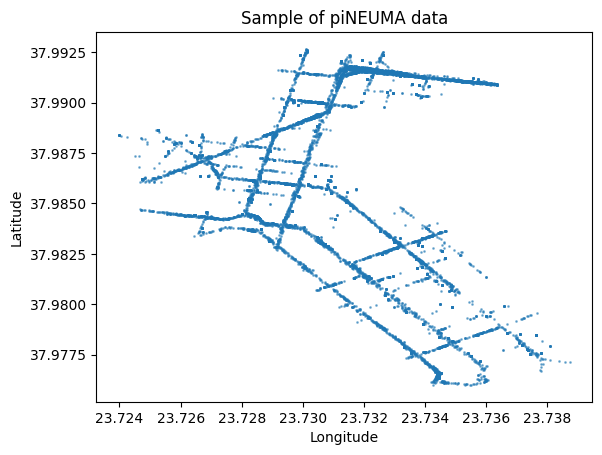

In [13]:
sample_df = df.sample(n=10000)
plt.scatter(sample_df["lon"], sample_df["lat"], s=1, alpha=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sample of piNEUMA data")
plt.show()

In [14]:
def in_boxspace(lat, lon, lat_min, lat_max, lon_min, lon_max):
    return (lat_min <= lat <= lat_max) and (lon_min <= lon <= lon_max)

def crosses_line(lat1, lat2, lat_line):
    return (lat1 < lat_line < lat2) or (lat2 < lat_line < lat1)

def compute_fundamental_data(df, lat_min, lat_max, lon_min, lon_max,
                             lat_upstream,
                             corridor_length_km,
                             t_start,
                             t_end,
                             bin_seconds=30):



    df = df.sort_values(["time", "track_id"]).reset_index(drop=True)

    results = []
    current_t = t_start
    df_time_filtered = df[(df["time"] >= t_start) & (df["time"] < t_end)]

    while current_t < t_end:
        bin_start = current_t
        bin_end   = current_t + bin_seconds


        bin_df = df_time_filtered[
            (df_time_filtered["time"] >= bin_start) &
            (df_time_filtered["time"] < bin_end)
        ]
        # density
        in_box_mask = (
            (bin_df["lat"] >= lat_min) & (bin_df["lat"] <= lat_max) &
            (bin_df["lon"] >= lon_min) & (bin_df["lon"] <= lon_max)
        )

        in_box_df = bin_df[in_box_mask]
        density_veh = in_box_df["track_id"].nunique()

        # to vehicles/km
        density = density_veh / corridor_length_km

        # flow
        crossing_vehicles = set()
        grouped_veh = bin_df.groupby("track_id", sort=False)

        for veh_id, group in grouped_veh:
            lat_values = group["lat"].values
            for i in range(len(lat_values) - 1):
                lat1, lat2 = lat_values[i], lat_values[i+1]
                if crosses_line(lat1, lat2, lat_upstream):
                    crossing_vehicles.add(veh_id)
                    break

        # vehicles in bin
        flow_count = len(crossing_vehicles)
        # Convert to vehicles/hour
        flow = flow_count / (bin_seconds / 3600.0)

        if len(in_box_df) > 0:
            avg_speed = in_box_df["speed"].mean()
        else:
            avg_speed = 0.0

        results.append([bin_start, density, flow, avg_speed])
        current_t += bin_seconds

    fd_df = pd.DataFrame(results, columns=["time_bin", "density", "flow", "speed"])
    return fd_df

t_min = df["time"].min()
t_max = df["time"].max()


time_start = t_min
time_end   = min(t_min + 1800, t_max)

fd_data = compute_fundamental_data(
    df,
    lat_min, lat_max, lon_min, lon_max,
    lat_upstream,
    corridor_length_km,
    t_start=time_start,
    t_end=time_end,
    bin_seconds= 30
)

print(fd_data.head())

   time_bin     density     flow      speed
0       0.0  869.460614  12840.0  12.434592
1      30.0  759.418826   8160.0  11.951948
2      60.0  648.072194  11640.0  12.023842
3      90.0  543.684726  11880.0   9.552458
4     120.0  466.264021   3840.0   7.264170


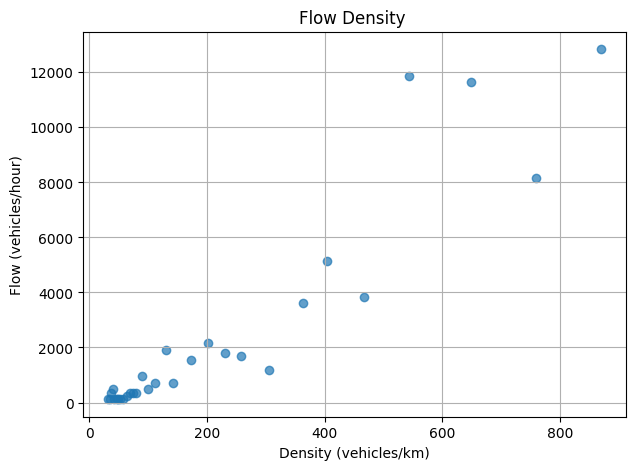

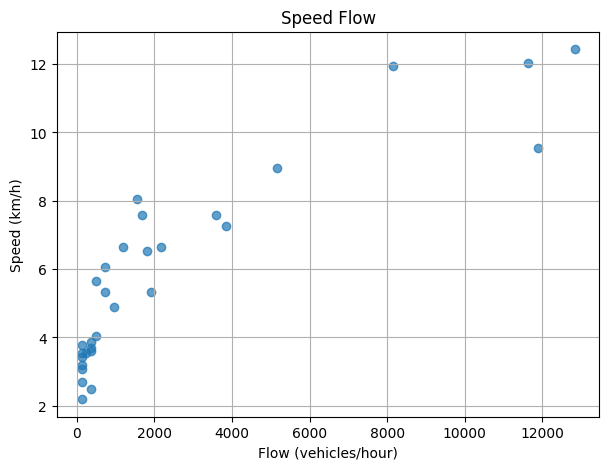

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(fd_data["density"], fd_data["flow"], alpha=0.7)
plt.title("Flow Density ")
plt.xlabel("Density (vehicles/km)")
plt.ylabel("Flow (vehicles/hour)")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(fd_data["flow"], fd_data["speed"], alpha=0.7)
plt.title("Speed Flow")
plt.xlabel("Flow (vehicles/hour)")
plt.ylabel("Speed (km/h)")
plt.grid(True)
plt.show()

In [16]:
from collections import defaultdict

def create_space_time_heatmap(
    df,
    x_min, x_max, nx,
    t_min, t_max, nt,
    value="density",
    x_col="x",
    t_col="t",
    speed_col="speed",
    track_col="track_id"
):

    x_edges = np.linspace(x_min, x_max, nx + 1)
    t_edges = np.linspace(t_min, t_max, nt + 1)

    bin_vehicle_sets = [[set() for _ in range(nt)] for _ in range(nx)]

    speed_sum = np.zeros((nx, nt), dtype=float)
    point_counts = np.zeros((nx, nt), dtype=int)

    df_filtered = df[
        (df[x_col] >= x_min) & (df[x_col] <= x_max) &
        (df[t_col] >= t_min) & (df[t_col] <= t_max)
    ]


    for _, row in df_filtered.iterrows():
        x_val = row[x_col]
        t_val = row[t_col]
        spd   = row[speed_col]
        vid   = row[track_col]

        i = np.searchsorted(x_edges, x_val) - 1
        j = np.searchsorted(t_edges, t_val) - 1

        if 0 <= i < nx and 0 <= j < nt:
            bin_vehicle_sets[i][j].add(vid)
            speed_sum[i, j] += spd
            point_counts[i, j] += 1

    dx_km = (x_max - x_min) / nx

    M = np.zeros((nx, nt), dtype=float)

    if value == "density":
        for i in range(nx):
            for j in range(nt):
                unique_veh_count = len(bin_vehicle_sets[i][j])
                M[i, j] = unique_veh_count / dx_km

    elif value == "speed":
        nonzero_mask = (point_counts > 0)
        M[nonzero_mask] = speed_sum[nonzero_mask] / point_counts[nonzero_mask]

    else:
        raise ValueError("value must be 'density' or 'speed'")

    return M, x_edges, t_edges

def plot_heatmap(M, x_edges, t_edges, value_label="Density"):
    fig, ax = plt.subplots(figsize=(8,5))

    extent = [t_edges[0], t_edges[-1], x_edges[0], x_edges[-1]]

    im = ax.imshow(M,
                   aspect='auto',
                   origin='lower',
                   extent=extent,
                   cmap='turbo')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(value_label)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Position (km)")
    ax.set_title(f"{value_label} in Space–Time")
    plt.show()

In [17]:
print(list(dataframes.keys()))


['df_LX830_1024', 'df_LX1030_1024', 'df_LX900_1024']


In [ ]:
df = dataframes["df_LX830_1024"].copy()
df.rename(columns={"traveled_d": "x", "time": "t"}, inplace=True)
# to km
df["x"] = df["x"] / 1000.0

x_min = df["x"].min()
x_max = df["x"].max()
t_min = df["t"].min()
t_max = df["t"].max()

spatial_bin_width = 0.1  # km
time_bin_width = 30      # seconds

# Compute number of bins:
nx = int((x_max - x_min) / spatial_bin_width)
nt = int((t_max - t_min) / time_bin_width)

speed_M, x_edges, t_edges = create_space_time_heatmap(
    df, x_min, x_max, nx,
    t_min, t_max, nt,
    value="speed"
)
plot_heatmap(speed_M, x_edges, t_edges, value_label="Speed (km/h)")

density_M, _, _ = create_space_time_heatmap(
    df, x_min, x_max, nx,
    t_min, t_max, nt,
    value="density"
)
plot_heatmap(density_M, x_edges, t_edges, value_label="Density (veh/km)")

Combining different time period in same location same date


In [ ]:
print(list(dataframes.keys()))

['df_LX830_1024', 'df_LX1030_1024', 'df_LX900_1024']


Traffic Data Analysis and Mapping with OSMnx

In [ ]:

import pandas as pd
import osmnx as ox
import geopandas as gpd

In [ ]:
# Load your traffic CSV file
df = pd.read_csv("../data/20181024_dX_0830_0900 (1).csv")
# Export to JSON if needed
json_output_path = "../data/2018_10_24_0830_0900traffic_data.json"
df.to_json(json_output_path, orient="records", indent=4)

In [ ]:
import osmnx as ox
print("osmnx version:", ox.__version__)


osmnx version: 2.0.2


In [ ]:
print(f"Latitude range: {lat_min} to {lat_max}")
print(f"Longitude range: {lon_min} to {lon_max}")


Latitude range: 37.975951 to 37.993033
Longitude range: 23.723609 to 23.738382


In [ ]:
import osmnx as ox

ox.settings.use_cache = True
ox.settings.cache_folder = "../cache"  # or any folder you'd like

# Then rerun your graph query
G = ox.graph.graph_from_bbox(
    bbox=(lat_min, lat_max, lon_min, lon_max),
    network_type="drive"
)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/osmnx/_overpass.py:267: UserWarning: This area is 860 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


In [ ]:
import time

start = time.time()

G = ox.graph.graph_from_bbox(
    bbox=(lat_min, lat_max, lon_min, lon_max),
    network_type="drive"
)

end = time.time()
print(f"✅ Road network downloaded in {end - start:.2f} seconds")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/osmnx/_overpass.py:267: UserWarning: This area is 860 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


: 

 Match GPS Points to Road Segments and Nodes

In [ ]:
import osmnx as ox

# Get bounding box from your GPS data
lat_min, lat_max = df["lat"].min(), df["lat"].max()
lon_min, lon_max = df["lon"].min(), df["lon"].max()

# Download the road network using the correct bbox keyword
G = ox.graph.graph_from_bbox(
    bbox=(lat_min, lat_max, lon_min, lon_max),
    network_type="drive"
)

# Project to UTM for accurate distance-based operations
G = ox.projection.project_graph(G)
target_crs = G.graph['crs']


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/osmnx/_overpass.py:267: UserWarning: This area is 860 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


KeyboardInterrupt: 

In [ ]:
# Use open street map to get the graph of the roads within your bounding box
G = ox.graph_from_bbox(lat_max, lat_min, lon_max, lon_min, network_type="drive", simplify=True)
G = ox.project_graph(G)
target_crs = G.graph['crs']


In [ ]:
# assign each of your points to the nearest road segment
# Pandas: normal dataframe
# Geopandas: dataframes for geodata
geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='epsg:4326')
gdf = gdf.to_crs(target_crs)

In [ ]:
# Find the nearest graph edge for each point
# Returns the form (u, v, key) for every point
## u, v are the nodes of the edge and the edge key
nearest_edges = ox.nearest_edges(G, gdf['geometry'].x, gdf['geometry'].y)


In [ ]:
# Find the nearest node for each point (nodes are intersections
nearest_nodes = ox.nearest_nodes(G, gdf['geometry'].x, gdf['geometry'].y)


In [ ]:
# Add this as a column back into your original dataframe
df['nearest_edge'] = pd.Series(nearest_edges).astype(str)
df['segment_id'] = df['nearest_edge']
df['nearest_node'] = pd.Series('nearest_nodes')


In [ ]:
# Convert to json
df_serializable = df.astype(object)
df_serializable.to_json("traffic_data_{file_id}.json", orient="records", indent=4)

In [ ]:
# 4. Calculate average speed and total number of vehicles on each individual road segment.

# Calculate the means for each distinct segment ID (i.e. each road segment)
avg_speed_per_segment = df.groupby("segment_id")['speed'].mean()

In [ ]:
# Calculate the total unique vehicles per segment 
vehicles_per_segment = df.groupby("segment_id")['track_id'].nunique()

# Combine these into a new metrics data frame
segment_metrics_df = pd.DataFrame({
  'avg_speed': avg_speed_per_segment,
  'totalvehicles': vehicles_per_segment
}).reset_indext()

In [ ]:
# 5. Calculate the turning ratio on each intersection

# Group the data by track id (i.e. each car)
for track_id, track_data in df.groupby('track_id'):
  
  # Get the sequence of roads (segments) for this car
  segment_sequence = track_data['segment_id'].tolist()
  # Get the sequence of intersections (nodes) for this car
  node_sequence = track_data['segment_id'].tolist()
  
  for i in range(len(segment_sequence) - 1):
    from_segment = segment_sequence[i]
    to_segment = segment_sequence[i + 1]
    intersection_node = node_sequence[i]

In [ ]:
  # Check to see if the from_segment != to_segment (a turn happened!)
 # Record in a dictionary the node, from segment, and to_segment and keep counting them up

from collections import defaultdict

# Dictionary structure:
# counts[node][from_segment][to_segment] = count
turning_dict = defaultdict(lambda: defaultdict(lambda: defaultdict(int)))

for track_id, group in df.groupby("track_id"):
    group = group.sort_values("time")  # ensure ordered

    segments = group["segment_id"].tolist()
    nodes = group["intersection_id"].tolist()  # use actual intersection if you have it

    for i in range(len(segments) - 1):
        from_seg = segments[i]
        to_seg = segments[i + 1]
        node = nodes[i]  # the intersection where the turn happens

        if from_seg != to_seg:
            turning_dict[node][from_seg][to_seg] += 1

    # Check to see if the from_segment != to_segment (a turn happened!)


In [ ]:
    # Record in a dictionary the node, from segment, and to_segment and keep counting them up